# Homework 2: Spectral analysis

In this notebook we explore the convective and wave motions in terms of their spatial and temporal spectra.  In the final step we will combine spectral and statistical methods and compare how useful they are with regard to characterizing the different types of motions and distinguish between them.

We will again
* Load the 3D data for a given dump
* Extract the 3D velocity components in an already interpolated form on a sphere of given radius

We then perform:
* A Fourier analysis of the spherically averaged $u_\mathrm{r}$ magnitude at a given radius 
* A spectral decomposition of the $u_\mathrm{r}$ distribution on a sphere at a given radius 


Familiarize yourself with this template notebook. Then use this template to explore the following questions. 

#### Questions
1. What is the main difference between the $u_r$ spatial spectra for convective and wave regions. How could the key difference be captured in a quantifiable way? Implement this _metric_ and demonstrate how this metric changes for a few representative radii from the wave region into the convection region.
2. Create temporal spectra for different radii, including in the wave region, in the convection region and in the transition region. 
    * How does the length of the time series impact the spectrum? 
    * What is the difference between convection and wave region? Interpret the difference in terms of the underlying physics. 
    * Can you find a _metric_ also in this case that would reduce the difference between temporal spectra of the wave region and the convection region? 

In [24]:
%pylab ipympl
import os, sys, time
from multiprocessing import Pool
from scipy import stats
from scipy.optimize import curve_fit
from nugridpy import utils as ut

# for use on niagara jupyter 
#ppmpy_dir = '/scratch/f/fherwig/fherwig/repos/PyPPM'
# for use on ppmstar hub on https://www.ppmstar.org
ppmpy_dir = "/user/repos/PyPPM"

sys.path.insert(0,ppmpy_dir)
from ppmpy import ppm
print(inspect.getfile(ppm))

# set cycling combination of color-blind labels, glyphs, styles
lll= 2*['-', '--', ':', '-.']
markers = ['X','h','<','>','s','^','d','X','p']
random.shuffle(lll)
cb = ut.linestylecb # colours
CB_color_cycle = [cb(i)[2] for i in range(8)]
rc('axes', prop_cycle=(cycler('color', CB_color_cycle[0:8]) + cycler('marker',markers[0:8])+cycler('linestyle',lll)))
rc('axes', prop_cycle=(cycler('color', CB_color_cycle[0:8]) +cycler('linestyle',lll)))

# named tuple for using rprofs and momsdata
# moms data are almost always used alongside rprof data and therefore it is recommended 
# to create a convenient dictionary that will hold the rprof and moms instance 
import collections
hydro = collections.namedtuple('hydro', ['moms','rprof'])

# turn off matplotlib messages
logging.getLogger("matplotlib").setLevel(logging.CRITICAL)

def fig_init(ifig=1):
    close(ifig);figure(ifig)

Populating the interactive namespace from numpy and matplotlib
/user/repos/PyPPM/ppmpy/ppm.py


In [25]:
# there are two data access points
# the first is slow but has all dumps, loading one dump takes about 20min
data_dir = '/user/niagara.scratch.ppmstar'
# the second is faster, but has only these dumps:
# 4120  4183  4325  4447  4474  4550
# use this as a default
data_dir = '/data/ASDR-team/PPMstar/H-core-M25/'
run_dir = 'M276-1000x-768'

moms_dir = os.path.join(data_dir,run_dir,'moms/myavsbq')
rprof_dir = os.path.join(data_dir,run_dir,'prfs')

# M276 - a list of variables available in these moms files:
var_list = ['xc','ux','uy','uz','|ut|','|ur|','|w|','T','rho','fv'] 
dump = 4447    # initialize with this dump

In [26]:
# initialize a collection of an instance of a radial profile and 3D briquette data set (called "moms" data)
start_time = time.time()
myrun = hydro(ppm.MomsDataSet(moms_dir,init_dump_read=dump,dumps_in_mem=2,var_list=var_list,\
                              rprofset=ppm.RprofSet(rprof_dir),verbose=0),ppm.RprofSet(rprof_dir))
end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")

6567 rprof files found in '/data/ASDR-team/PPMstar/H-core-M25/M276-1000x-768/prfs/.
Dump numbers range from 0 to 6566.
6567 rprof files found in '/data/ASDR-team/PPMstar/H-core-M25/M276-1000x-768/prfs/.
Dump numbers range from 0 to 6566.
Execution time: 5.234411239624023 seconds


In [27]:
rph = myrun.rprof.get_history()
# rph.get_variables()

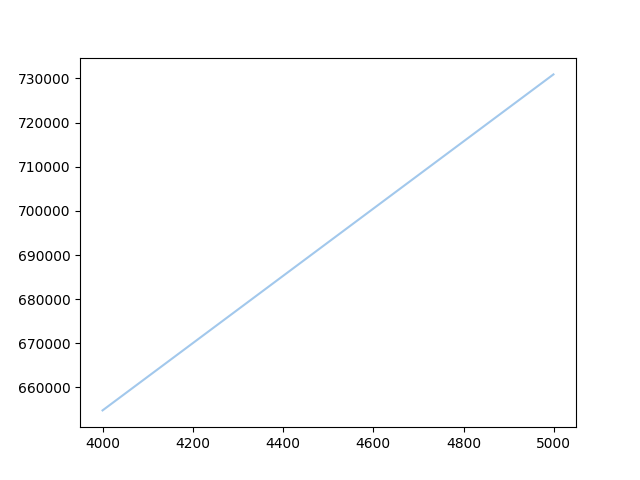

In [5]:
# make sure that we are plotting 
fig_init(302)
plot(rph.get('NDump'),rph.get('time(mins)'))

In [6]:
myrun.rprof.rprofgui(ifig=1,title=run_dir)

interactive(children=(IntSlider(value=4000, description='dump1', max=4999, min=4000), IntSlider(value=4782, de…

In [7]:
# see all variables available in profile data
# rp =  myrun.rprof.get_dump(4000)
# rp.get_lr_variables()

In [28]:
myradius=2200
radius = myrun.rprof.get('R',fname=4000)
# radius

In [29]:
ind = ppm.where_near(myradius,radius)
radius[ind]

2202.9438

In [30]:
times = []
things = []
thing_name = '|Ur|'

dump_min,dump_max = 4000,4999
step = 1
radius = myrun.rprof.get('R',dump_min)
ind = ppm.where_near(myradius,radius)
for dump in range(dump_min,dump_max+1,step):
    thing = myrun.rprof.get(thing_name,dump)
    things.append(thing[ind])
    time = myrun.rprof.get("t", fname=dump)
    times.append(time)
things=array(things)*1000 # make velocities in km/s
times = array(times)-times[0]

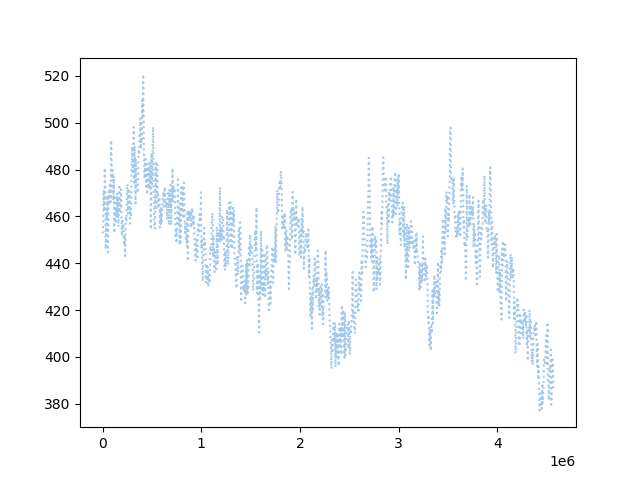

In [31]:
fig_init(23)
plot(times,things*1000)

In [32]:
# Compute the DFT
dft = np.fft.fft(things)

In [33]:
# Compute the frequencies
N = len(times)
time_spacing = times[1] - times[0]
frequencies = np.fft.fftfreq(N, time_spacing)

# Keep only positive frequencies
positive_frequencies = frequencies[:N // 2]
positive_dft = dft[:N // 2]

In [34]:
# Calculate the power spectrum
power_spectrum = np.abs(positive_dft)**2

Text(0, 0.5, 'Power Spectrum')

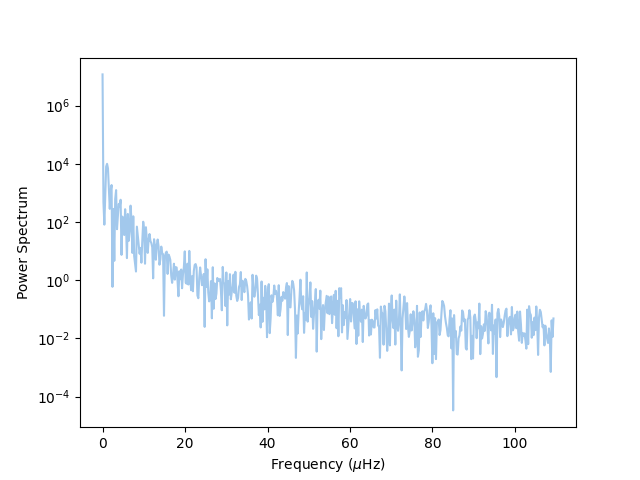

In [15]:
fig_init(34)
semilogy(positive_frequencies*1.e6, power_spectrum)
xlabel('Frequency ($\mu$Hz)')
ylabel('Power Spectrum')

Text(0, 0.5, 'Power Spectrum')

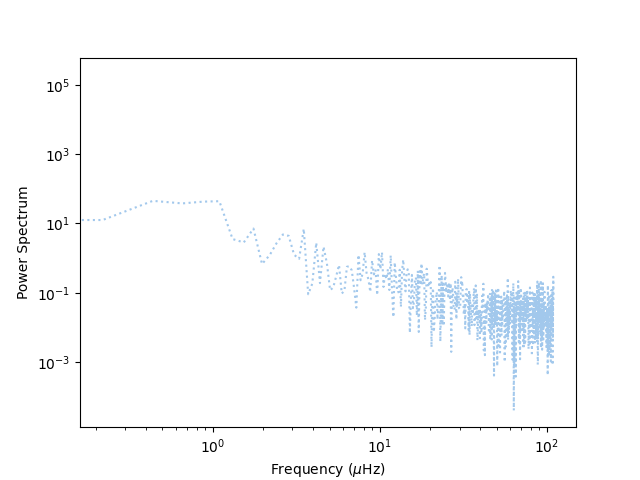

In [36]:
fig_init(36)
loglog(positive_frequencies*1.e6, power_spectrum)
xlabel('Frequency ($\mu$Hz)')
ylabel('Power Spectrum')

Text(0, 0.5, 'Power Spectrum')

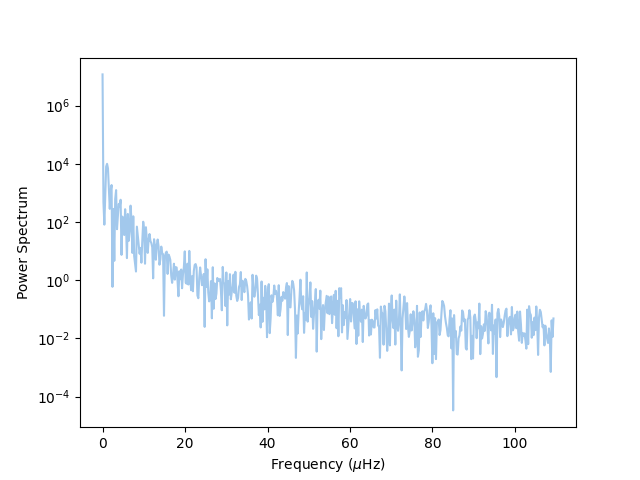

In [16]:
fig_init(35)
semilogy(positive_frequencies*1.e6, power_spectrum)
xlabel('Frequency ($\mu$Hz)')
ylabel('Power Spectrum')

## Spectral decomposition in Spherical Harmonics

We will be using the Python package [pyshtools](https://shtools.github.io/SHTOOLS/index.html).

In [17]:
import pyshtools.expand 
import pyshtools.spectralanalysis

In [18]:
# pyshtools.expand.SHExpandDH?

In [19]:
# pyshtools.spectralanalysis.spectrum?

### Expansion in spherical harmonics

In [20]:
# u_r analysis plots
myradius=1200
var = '|ur|'

# max npoints
lmax_r, N, npoints = myrun.moms.sphericalHarmonics_lmax(myradius)
print(lmax_r, N, npoints)

134 270 145800


In [21]:
# Calculate spherical harmonics up to lmax
var_interp = myrun.moms.sphericalHarmonics_format(var, myradius, lmax=lmax_r)
# get coefficients and power
coeffs = pyshtools.expand.SHExpandDH(var_interp, sampling=2)
power_ell = pyshtools.spectralanalysis.spectrum(coeffs, unit='per_l')
ell = np.arange(0, lmax_r+1)

Text(4.319999999999999, 3530.204258030974, '$l^{-5/3}$')

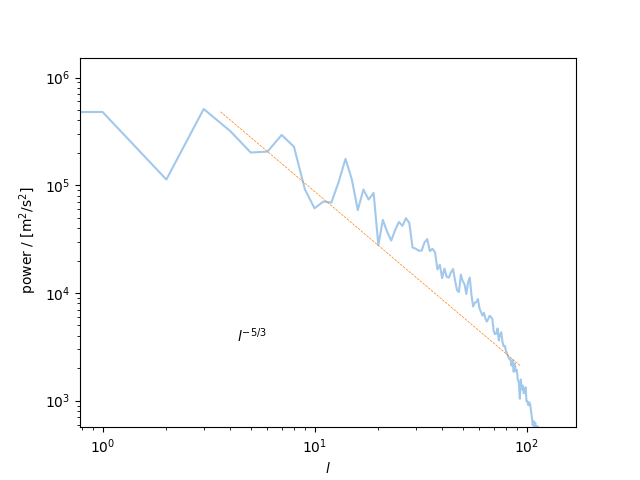

In [22]:
fig_init(197)
loglog(ell, 1.e12*power_ell,'-')
ell_scale = 6
xx = np.linspace(0.6*ell_scale,0.7*ell[-1],5)
fac = 1./(ell_scale**(-5/3))
pow_scale = float(power_ell[ell == ell_scale])
pmax = 1.e12*power_ell.max()
loglog(xx,1.e12*pow_scale*fac*xx**(-5/3),'--',lw=0.5,)
ylim(3*1e12*power_ell[-1],3*pmax)
ylabel(' power / $\mathrm{[m^2/s^2]}$'); xlabel('$l$')
text(1.2*xx[0],0.2*1.e12*pow_scale*fac*xx[1]**(-5/3),'$l^{-5/3}$')